# Synthetic Look-Ahead Alpha Construction



## Baseline Notebook Construction

This notebook constructs a synthetic alpha process from realized intraday returns. Let

$$
r_t
$$

denote the realized intraday return at time $t$. The solution to the exercise proposed in class generates a synthetic return innovation process of the form

$$
\tilde{\alpha}_t = x r_t + y \varepsilon_t,
$$

where:
- $r_t$ is the realized return,
- $\varepsilon_t \sim \mathcal{N}(0,1)$ is independent Gaussian noise,
- $x$ and $y$ are calibrated such that the synthetic innovations achieve a target correlation $\rho$ with realized returns. 
Namely, for a target correlation $\rho$, we solve for x and y and obtain : 
$$
x=\rho
$$

and 

$$y=\sigma_r\sqrt{1-\rho^2}$$


The notebook from lectures then constructs the synthetic alpha process through cumulative summation:

$$
\alpha_t = \sum_{s \le t} \tilde{\alpha}_s.
$$

Equivalently,

$$
\alpha_t = \alpha_{t-1} + \tilde{\alpha}_t.
$$
 It then compares this synthetic alpha process with the cumulative intraday return:

$$
\frac{P_t}{P_0} - 1,
$$

where $P_t$ denotes the stock price at time $t$.

Importantly, this quantity is not a one-step forward return but rather the cumulative realized intraday return path.



# Limitation of this Construction

This cumulative sum construction implies:

$$
\alpha_t = \alpha_{t-1} + \tilde{\alpha}_t,
$$

which corresponds to a random walk process with infinite persistence.

This creates several issues:
- the variance of the alpha process grows indefinitely over time,
- old information never disappears,
- the signal becomes nonstationary,
- noise accumulates permanently.

As a consequence, the synthetic alpha process can become unrealistically large and unstable.





# Introducing Alpha Decay

To address this issue, we extend the baseline construction by introducing exponential alpha decay.

Instead of using a cumulative sum, we define the alpha dynamics as:

$$
\alpha_t = \phi \alpha_{t-1} + \tilde{\alpha}_t,
$$

where:
- $0 < \phi < 1$ is a persistence parameter,
- $\tilde{\alpha}_t$ denotes the synthetic alpha innovation.

The persistence parameter is linked to an alpha half-life $h$ through:

$$
\phi = \exp\left(-\frac{\ln(2)\Delta t}{h}\right),
$$

where:
- $h$ is the half-life in seconds,
- $\Delta t$ is the sampling interval.

The half-life determines how quickly old information decays. For example, with a half-life of 1800 seconds, the contribution of a shock is reduced by 50% after 30 minutes.

This modification creates a stationary and more realistic latent alpha process:
- old information gradually fades,
- variance remains bounded,
- the signal remains persistent but no longer explodes.



# Correlation Interpretation

The target correlation $\rho$ is imposed on the innovation process:

$$
\tilde{\alpha}_t = x r_t + y \varepsilon_t,
$$

not necessarily on the final decayed alpha state $\alpha_t$.

After introducing persistence,

$$
\alpha_t = \phi \alpha_{t-1} + \tilde{\alpha}_t,
$$

the alpha state contains accumulated historical information. Consequently:
- the alpha process becomes smoother,
- its variance structure changes,
- its instantaneous correlation with realized returns is no longer exactly equal to the target $\rho$.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

train_px_df = pd.read_csv("data/train_px_201901_20.csv")
train_px_df = train_px_df.set_index(["stock", "date"]).ffill(axis="columns").bfill(axis="columns")

In [7]:
returns = train_px_df.pct_change(1, axis="columns").ffill(axis="columns").bfill(axis="columns")
returns = returns.unstack()
variance_returns = returns.T.var()
mean_inverse_prices= (train_px_df ** (-2)).groupby(level="stock").mean().T.mean()

In [50]:
stock="AAPL"
required_corr = 0.9
stock_px_df = train_px_df.loc[stock]
x = required_corr ** 2
y = required_corr * np.sqrt(1 - required_corr ** 2) * np.sqrt(variance_returns[stock] / mean_inverse_prices[stock])
print(f"Variance of realized alpha: {variance_returns[stock]}")
print(f"(x,y)=({x},{y})")

Variance of realized alpha: 8.90433625191339e-08
(x,y)=(0.81,0.01797756402702856)


In [55]:
np.random.seed(45)
px_changes = stock_px_df.T.diff(1, axis=0).iloc[1:,:]
W_diffs = np.random.normal(loc=0, scale=1.0, size=(stock_px_df.shape[0], stock_px_df.shape[1]-1))
Ws = np.concatenate([np.zeros((W_diffs.shape[0], 1)), W_diffs.cumsum(axis=1)], axis=1).T
W_h_diffs = Ws[1:,:] - Ws[:-1,:]
px_changes = px_changes * x + W_h_diffs * y
synthetic_returns = (px_changes / (stock_px_df.T.shift(1, axis=0)))

synthetic_returns.index.name = "time"
synthetic_returns.columns.name = "date"

# Convert to long format
synthetic_series = synthetic_returns.stack()
synthetic_series.name = "synthetic"

# Actual returns
actual_series = returns.loc[stock]
actual_series.name = "actual"

returns_df = pd.concat(
    [actual_series, synthetic_series],
    axis=1
).dropna()

returns_df.index = returns_df.index.set_names(["time", "date"])

correlation = returns_df.corr().iloc[0,1]
actual_variance = returns_df["actual"].var()
synthetic_variance = returns_df["synthetic"].var()
synthetic_alpha_diffs = returns_df.drop("actual", axis="columns").unstack("time")["synthetic"]


alpha_half_life = 1800  #  30 min in seconds
dt = 10              # sampling interval in seconds

beta = np.log(2) / alpha_half_life
decay_factor = np.exp(-beta * dt)

synthetic_alphas = synthetic_alpha_diffs.copy()

synthetic_alphas.iloc[:, 0] = synthetic_alpha_diffs.iloc[:, 0]

for t in range(1, synthetic_alpha_diffs.shape[1]):
    synthetic_alphas.iloc[:, t] = (
        decay_factor * synthetic_alphas.iloc[:, t - 1]
        + synthetic_alpha_diffs.iloc[:, t]
    )

print(f"Variance of synthetic alpha: {synthetic_variance}")
print(f"Correlation with the realized alpha: {correlation}")

Variance of synthetic alpha: 7.099089151062304e-08
Correlation with the realized alpha: 0.8992593598402457


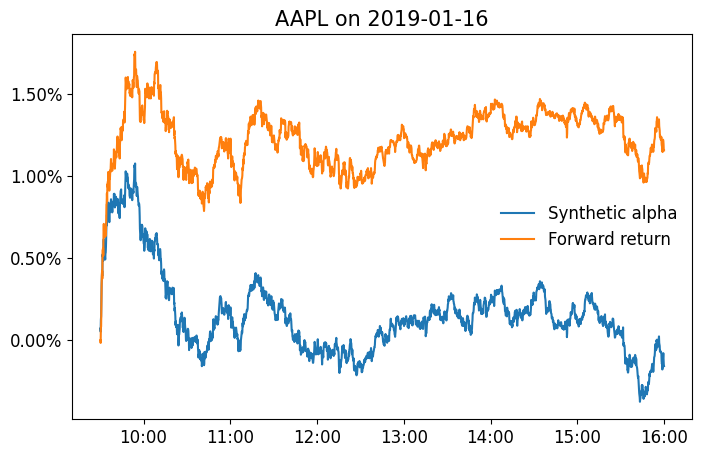

In [64]:
date = "2019-01-16"

common_times = synthetic_alphas.columns.intersection(stock_px_df.columns)


fig = plt.figure(figsize=(8,5))
ax = plt.subplot(111)
ax.plot(pd.to_datetime(common_times, format='%H:%M:%S'), synthetic_alphas.loc[date].values, label="Synthetic alpha")
ax.plot(pd.to_datetime(common_times, format='%H:%M:%S'), stock_px_df.loc[date].reindex(common_times) / stock_px_df.loc[date].reindex(common_times).iloc[0] - 1, label="Forward return")
ax.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title(f"{stock} on {date}", fontsize=15)
xfmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(xfmt)
ax.legend(fontsize=12, frameon=False)
plt.show()